# Matplotlib Assignment
This notebook demonstrates various data visualization techniques using pure Matplotlib and Pandas (for data manipulation only).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    df = pd.read_csv('Walmart_Sales.csv')
except FileNotFoundError:
    print('Error: Walmart_Sales.csv not found in the current directory.')

## Task 1: Line Chart

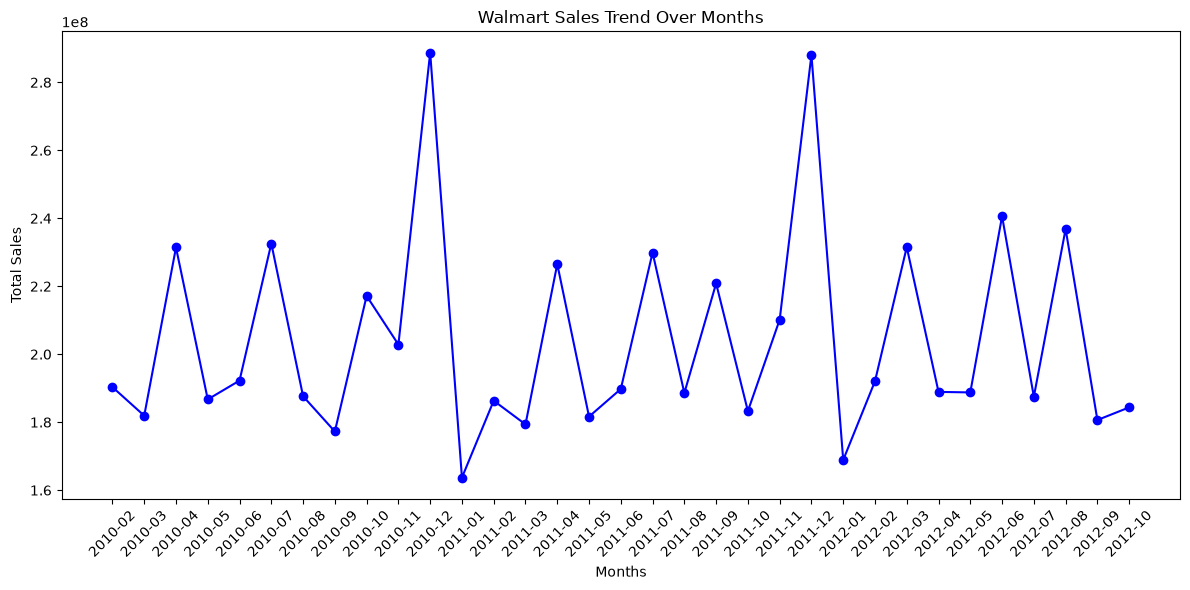

In [ ]:
df_copy = df.copy()
df_copy['Date'] = pd.to_datetime(df_copy['Date'], dayfirst=True, errors='coerce')
monthly_sales = df_copy.groupby(df_copy['Date'].dt.to_period('M'))['Weekly_Sales'].sum()
x_values = monthly_sales.index.astype(str)
y_values = monthly_sales.values
plt.figure(figsize=(12, 6))
plt.plot(x_values, y_values, marker='o', linestyle='-', color='b')
plt.title('Walmart Sales Trend Over Months')
plt.xlabel('Months')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 2: Scatter Plot

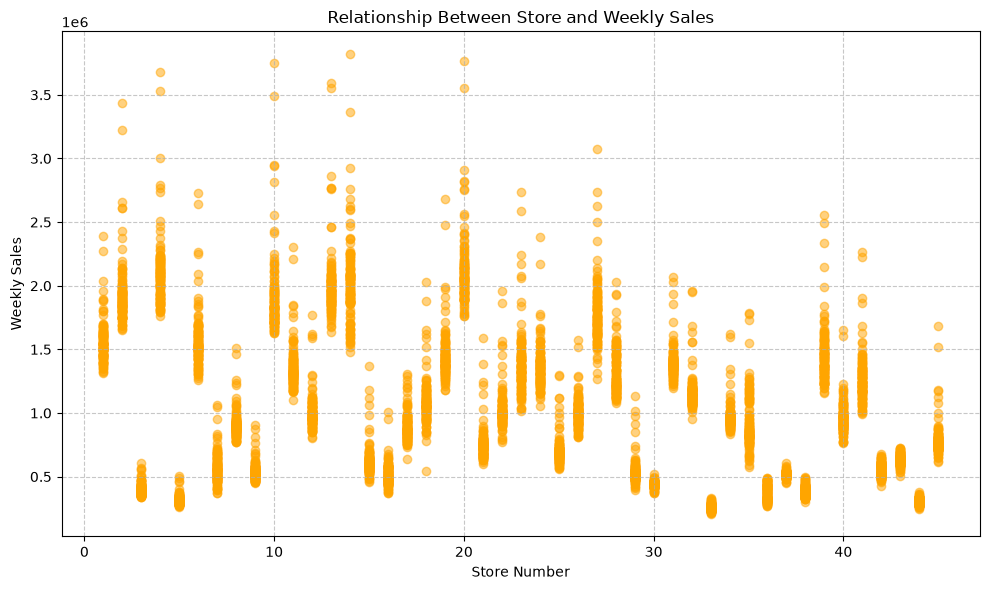

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Store'], df['Weekly_Sales'], alpha=0.5, color='orange')
plt.title('Relationship Between Store and Weekly Sales')
plt.xlabel('Store Number')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Task 3: Bar Charts

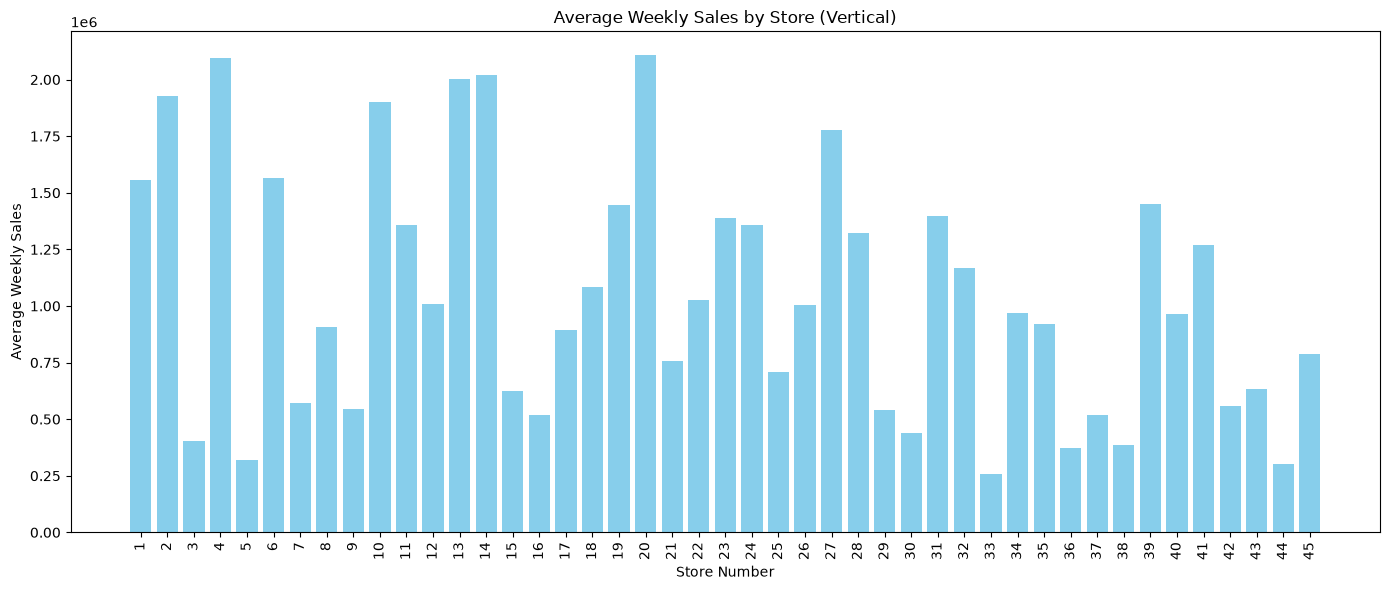

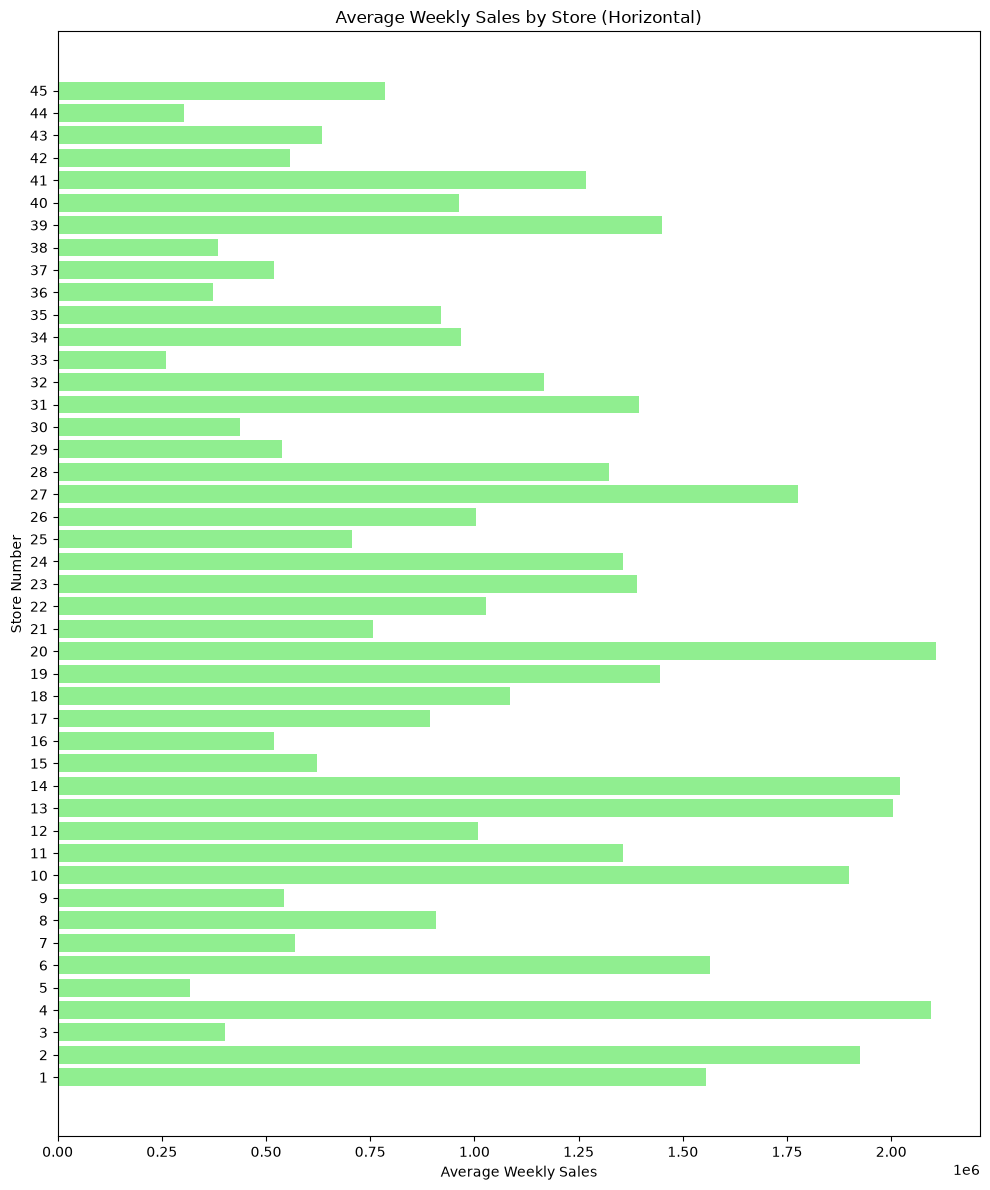

In [4]:
store_sales = df.groupby('Store')['Weekly_Sales'].mean()
plt.figure(figsize=(14, 6))
plt.bar(store_sales.index, store_sales.values, color='skyblue')
plt.title('Average Weekly Sales by Store (Vertical)')
plt.xlabel('Store Number')
plt.ylabel('Average Weekly Sales')
plt.xticks(store_sales.index, rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 12))
plt.barh(store_sales.index, store_sales.values, color='lightgreen')
plt.title('Average Weekly Sales by Store (Horizontal)')
plt.xlabel('Average Weekly Sales')
plt.ylabel('Store Number')
plt.yticks(store_sales.index)
plt.tight_layout()
plt.show()

## Task 4: Multiple Bar Chart

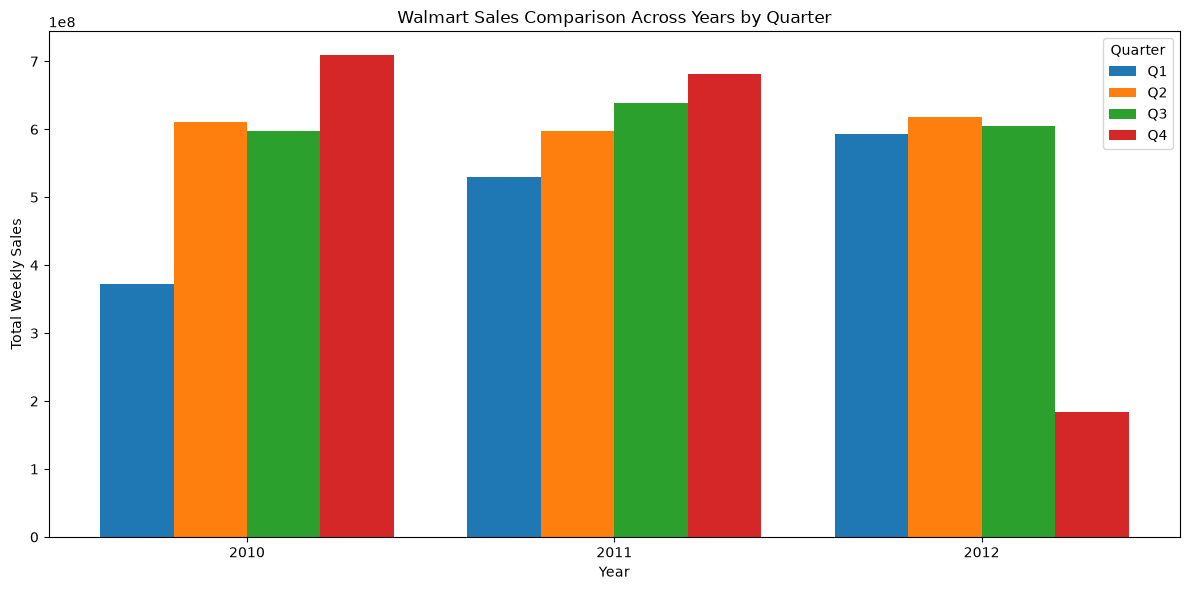

In [5]:
df_copy = df.copy()
df_copy['Date'] = pd.to_datetime(df_copy['Date'], dayfirst=True, errors='coerce')
df_copy['Year'] = df_copy['Date'].dt.year
df_copy['Quarter'] = df_copy['Date'].dt.quarter
sales_by_yq = df_copy.groupby(['Year', 'Quarter'])['Weekly_Sales'].sum().unstack(fill_value=0)
years = sales_by_yq.index
quarters = sales_by_yq.columns
x = np.arange(len(years))
width = 0.2
plt.figure(figsize=(12, 6))
for i, quarter in enumerate(quarters):
    offset = (i - len(quarters)/2) * width + width/2
    plt.bar(x + offset, sales_by_yq[quarter], width, label=f'Q{quarter}')
plt.title('Walmart Sales Comparison Across Years by Quarter')
plt.xlabel('Year')
plt.ylabel('Total Weekly Sales')
plt.xticks(x, years)
plt.legend(title='Quarter')
plt.tight_layout()
plt.show()

## Task 5: Stacked Bar Chart

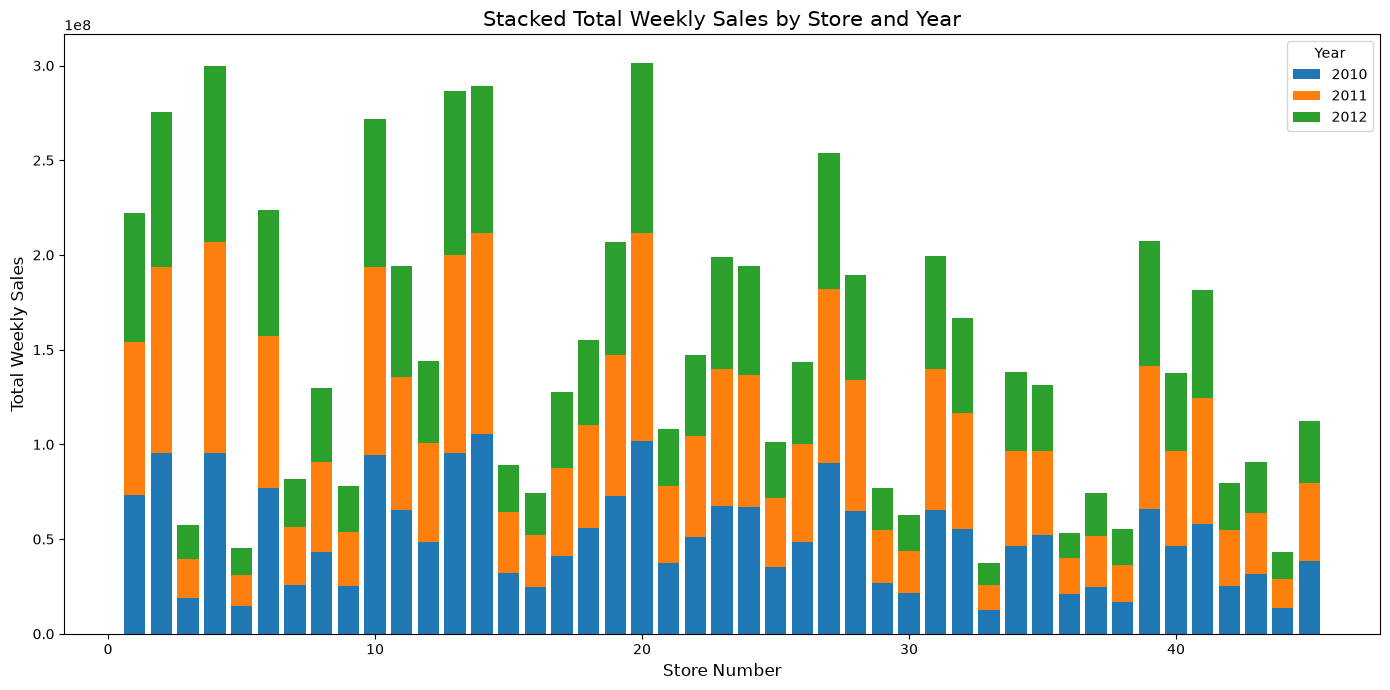

In [6]:
df_copy = df.copy()
df_copy['Date'] = pd.to_datetime(df_copy['Date'], dayfirst=True, errors='coerce')
df_copy['Year'] = df_copy['Date'].dt.year
sales_by_store_year = df_copy.groupby(['Store', 'Year'])['Weekly_Sales'].sum().unstack(fill_value=0)

years = sales_by_store_year.columns
stores = sales_by_store_year.index

plt.figure(figsize=(14, 7))
bottom = np.zeros(len(stores))

for year in years:
    plt.bar(stores, sales_by_store_year[year], bottom=bottom, label=str(year), width=0.8)
    bottom += sales_by_store_year[year].values

plt.title('Stacked Total Weekly Sales by Store and Year', fontsize=15)
plt.xlabel('Store Number', fontsize=12)
plt.ylabel('Total Weekly Sales', fontsize=12)
plt.legend(title='Year')
plt.tight_layout()
plt.show()


## Task 6: Histogram

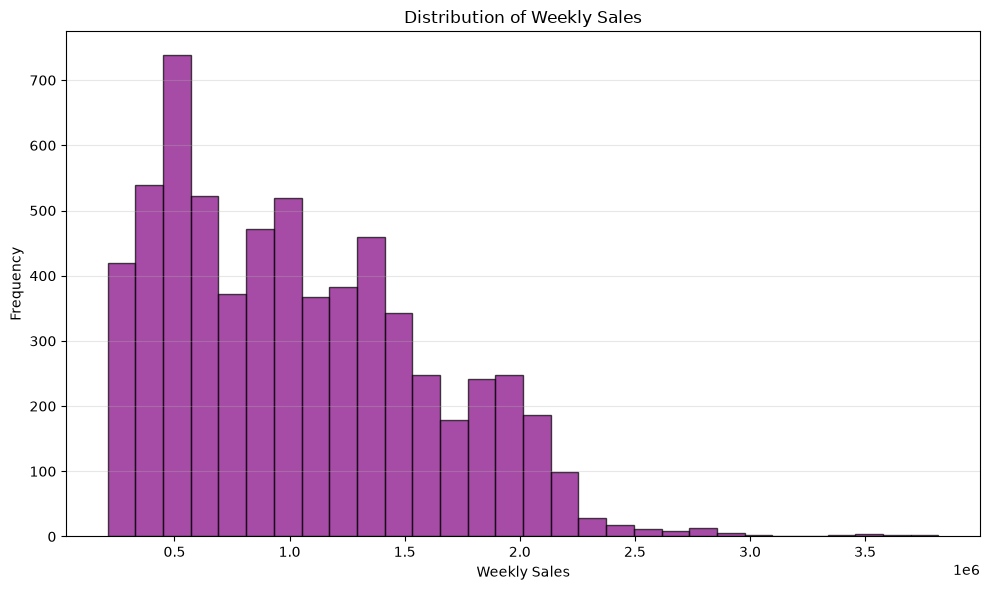

In [7]:
sales = df['Weekly_Sales'].dropna()
plt.figure(figsize=(10, 6))
plt.hist(sales, bins=30, edgecolor='black', alpha=0.7, color='purple')
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Task 7: Pie Chart

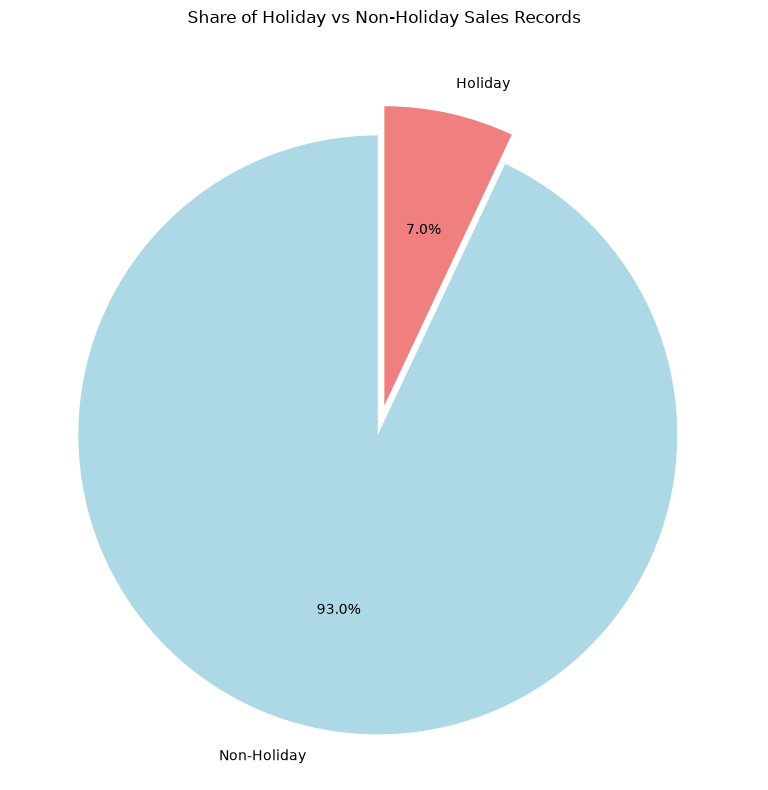

In [8]:
category_counts = df['Holiday_Flag'].map({0: 'Non-Holiday', 1: 'Holiday'}).value_counts()
plt.figure(figsize=(8, 8))
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'], explode=(0.1, 0))
plt.title('Share of Holiday vs Non-Holiday Sales Records')
plt.tight_layout()
plt.show()